# Librerie

In [64]:
using Plots # Libreria per la visualizzazione dei dati

# Richieste
Calcolare la seguente somma
$$
\sum_{n=1}^{\infty} \frac{1}{n^{2}} = \frac{\pi^{2}}{6} = \lim_{ N \to \infty } S(N); \quad S(N) = \sum_{n=1}^{N} \frac{1}{n^{2}}
$$
- Calcolare la somma in 'single precision' utilizzando il 'normal ordering', $n = 1, 2, 3, \dots, N$
- Calcolare la somma in 'single precision' utilizzando il 'reverse ordering', $n = N, \dots , 2, 1$
- Studiare la convergenza di entrambe le implementazioni in funzione di $N$ plottando $\left\lvert  S(N) - \frac{\pi^{2}}{6}  \right\rvert$
- Ripetere i primi tre punti in 'double precision'

# Funzioni

In [65]:
function somma_no(n::Int, precision::Char)
    """
    Calcola la somma dei numeri interi da 1 ad 1 / n^2 in normal ordering.
    Argomenti:
    - `a::Int`: un numero intero positivo
    - `precision::Char`: 'S' per single precision, 'D' per double precision
    Ritorna:
    - `s::Float64`: la somma dei numeri da 1 a 1 / n^2
    """
    if precision == 'S'
        s = Float32(0)
        for i in 1:n
            s += Float32(1 / i^2)
        end
        return s
    end 

    if precision == 'D'
        s = Float64(0)
        for i in 1:n
            s += Float64(1 / i^2)
        end
        return s
    end
end

function somma_ro(n::Int, precision::Char)
    """
    Calcola la somma dei numeri interi da 1 ad 1 / n^2 in reverse ordering.
    Argomenti:
    - `a::Int`: un numero intero positivo
    - `precision::Char`: 'S' per single precision, 'D' per double precision
    Ritorna:
    - `s::Float64`: la somma dei numeri da 1 a 1 / n^2
    """
    if precision == 'S'
        s = Float32(0)
        for i in n:-1:1
            s += Float32(1 / i^2)
        end
        return s
    end
    if precision == 'D'
        s = Float64(0)
        for i in n:-1:1
            s += Float64(1 / i^2)
        end
        return s
    end
end

conv_no(n, t) = abs(somma_no(n, t) - pi^2 / 6) # Errore assoluto per normal ordering
conv_ro(n, t) = abs(somma_ro(n, t) - pi^2 / 6) # Errore assoluto per reverse ordering

conv_ro (generic function with 1 method)

In [75]:
function optz_so(N::Int, precision::Char)
    if precision == 'S'
        a = Float32[1 / n^2 for n in 1:N]
        s1 = zeros(Float32, N)
        s2 = zeros(Float32, N)
    end

    if precision == 'D'
        a = Float64[1 / n^2 for n in 1:N]
        s1 = zeros(Float64, N)
        s2 = zeros(Float64, N)
    end

    for n = 1:N
        for k = 1:N
            s1[k] = a[k]
            s2[k] = a[N - k + 1]
        end
    end

    err1 = @. abs(s1 - pi^2 / 6)
    err2 = @. abs(s2 - pi^2 / 6)

    return s1, s2, err1, err2
end

optz_so (generic function with 1 method)

# Dati

In [76]:
n = range(10, stop=10^5, step=100)

10:100:99910

# Single Precision

## Normal Ordering VS Reverse Ordering
- Calcolare la somma in 'single precision' utilizzando il 'normal ordering', $n = 1, 2, 3, \dots, N$
- Calcolare la somma in 'single precision' utilizzando il 'reverse ordering', $n = N, \dots , 2, 1$

In [78]:
s_no, s_ro, err_no, err_ro = optz_so(10^5, 'S')
plot(n, [s_no, s_ro], 
    xlabel="n", ylabel="Somma", 
    title="Somma in funzione di n", 
    label=["Normal Ordering" "Reverse Ordering"])


## Studio della convergenza
Studiare la convergenza di entrambe le implementazioni in funzione di $N$ plottando $\left\lvert  S(N) - \frac{\pi^{2}}{6}  \right\rvert$

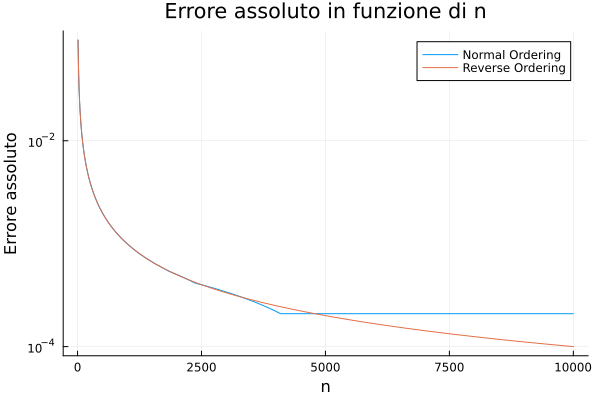

In [69]:
n_s = range(10, stop=10^4, step=10)
plot(n_s, [conv_no.(n_s, 'S'), conv_ro.(n_s, 'S')], 
    xlabel="n", ylabel="Errore assoluto", 
    title="Errore assoluto in funzione di n",
    yscale=:log10,
    label=["Normal Ordering" "Reverse Ordering"])

### Punto di separazione tra 'normal ordering' e 'reverse ordering'
Si vuole ora capire quando le due curve, quella della 'normal precision' e qualla della 'reverse precision' si separano e perché.

Il minimo del rapporto è 0.8558213453070901 e si trova a n = 4100


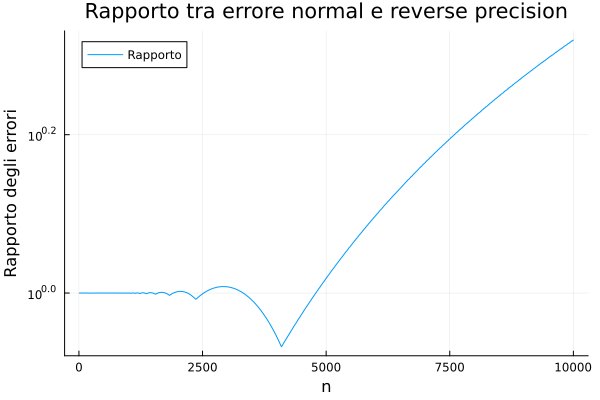

In [70]:
ratio = conv_no.(n_s, 'S') ./ conv_ro.(n_s, 'S')
minimum_ratio = minimum(ratio)

println("Il minimo del rapporto è ", minimum_ratio, " e si trova a n = ", n_s[findfirst(ratio .== minimum_ratio)])

plot(n_s, ratio, 
    xlabel="n", ylabel="Rapporto degli errori", 
    title="Rapporto tra errore normal e reverse precision",
    yscale=:log10,
    label="Rapporto")

C'è una separazione dei risultati intorno a $n = 4100$.

# Double Precision

## Normal Ordering VS Reverse Ordering
- Calcolare la somma in 'double precision' utilizzando il 'normal ordering', $n = 1, 2, 3, \dots, N$
- Calcolare la somma in 'double precision' utilizzando il 'reverse ordering', $n = N, \dots , 2, 1$

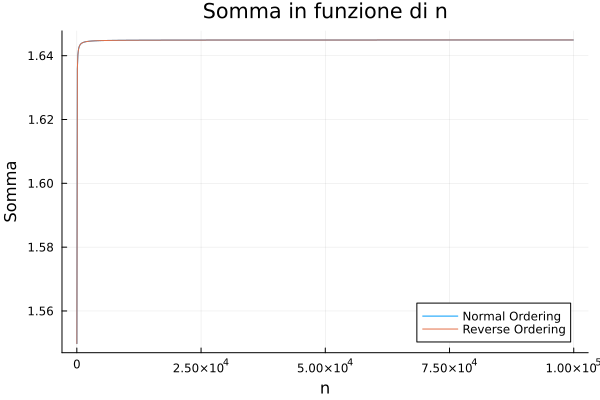

In [71]:
plot(n, [somma_no.(n, 'D'), somma_ro.(n, 'D')], 
    xlabel="n", ylabel="Somma", 
    title="Somma in funzione di n", 
    label=["Normal Ordering" "Reverse Ordering"])

## Studio della convergenza

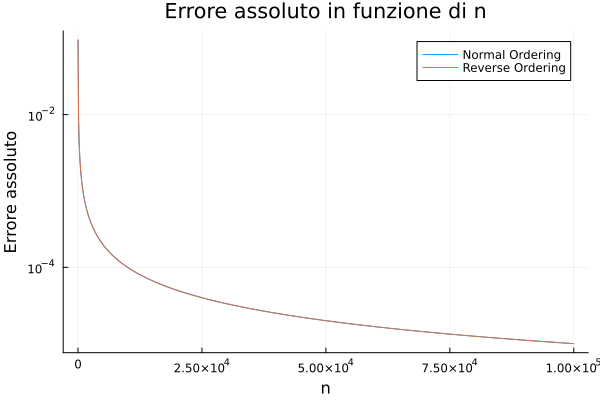

In [72]:
plot(n, [conv_no.(n, 'D'), conv_ro.(n, 'D')], 
    xlabel="n", ylabel="Errore assoluto", 
    title="Errore assoluto in funzione di n",
    yscale=:log10,
    label=["Normal Ordering" "Reverse Ordering"])

Il minimo del rapporto è 0.9999999976152416 e si trova a n = 9430


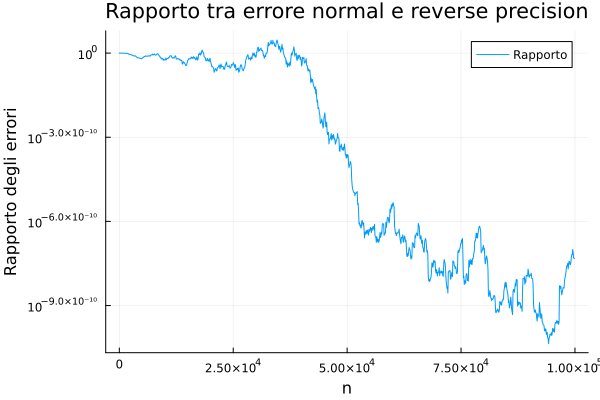

In [73]:
ratio = conv_no.(n, 'D') ./ conv_ro.(n, 'D')
minimum_ratio = minimum(ratio)

println("Il minimo del rapporto è ", minimum_ratio, " e si trova a n = ", n_s[findfirst(ratio .== minimum_ratio)])

plot(n, ratio, 
    xlabel="n", ylabel="Rapporto degli errori", 
    title="Rapporto tra errore normal e reverse precision",
    yscale=:log10,
    label="Rapporto")